In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
sns.set()


# PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING

In [4]:
# 1. Viết hàm load_data() để tải dữ liệu lên ứng dụng. Sau đó, hiển thị ra màn hình 10 dòng đầu tiên
def load_data():
    df = pd.read_csv("titanic_disaster.csv")
    return df

df = load_data()
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


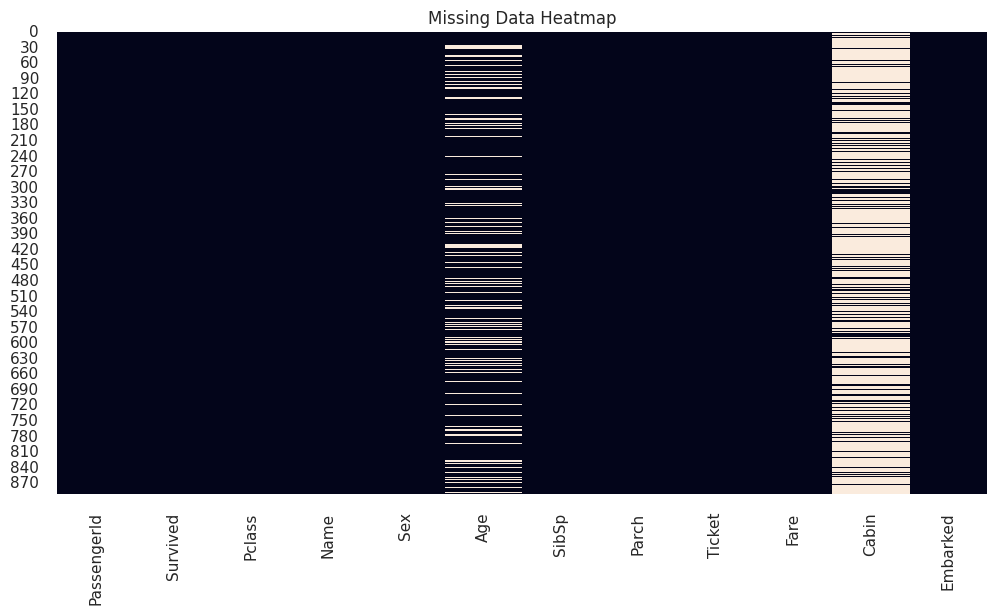

In [5]:
# 2. Thống kê dữ liệu thiếu trên các biến số và trực quan hóa dữ liệu thiếu bằng biểu đồ (Heat map).
# Hãy cho nhận xét về tình trạng thiếu dữ liệu Age, Cabin và Embarked
df.isnull().sum()
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

In [6]:
# 3. Xử lý tên cột tên Name, tách ra làm 2 cột: firstName và secondName.
# Lưu ý: Sau khi tách cột xong thì xóa luôn cột Name
df[['Lastname','Firstname']] = df['Name'].str.split(',', n=1, expand=True)
df = df.drop('Name', axis=1)
print (df)

     PassengerId  Survived  Pclass     Sex   Age  SibSp  Parch  \
0              1         0       3    male  22.0      1      0   
1              2         1       1  female  38.0      1      0   
2              3         1       3  female  26.0      0      0   
3              4         1       1  female  35.0      1      0   
4              5         0       3    male  35.0      0      0   
..           ...       ...     ...     ...   ...    ...    ...   
886          887         0       2    male  27.0      0      0   
887          888         1       1  female  19.0      0      0   
888          889         0       3  female   NaN      1      2   
889          890         1       1    male  26.0      0      0   
890          891         0       3    male  32.0      0      0   

               Ticket     Fare Cabin Embarked   Lastname  \
0           A/5 21171   7.2500   NaN        S     Braund   
1            PC 17599  71.2833   C85        C    Cumings   
2    STON/O2. 3101282   7.9

In [7]:
# 4. Xứ lý rút gọn kích thước dữ liệu trên cột Sex như sau: thay thế male → M và female → F
df['Sex'] = df['Sex'].replace({'male': 'M', 'female': 'F'})
print (df)

     PassengerId  Survived  Pclass Sex   Age  SibSp  Parch            Ticket  \
0              1         0       3   M  22.0      1      0         A/5 21171   
1              2         1       1   F  38.0      1      0          PC 17599   
2              3         1       3   F  26.0      0      0  STON/O2. 3101282   
3              4         1       1   F  35.0      1      0            113803   
4              5         0       3   M  35.0      0      0            373450   
..           ...       ...     ...  ..   ...    ...    ...               ...   
886          887         0       2   M  27.0      0      0            211536   
887          888         1       1   F  19.0      0      0            112053   
888          889         0       3   F   NaN      1      2        W./C. 6607   
889          890         1       1   M  26.0      0      0            111369   
890          891         0       3   M  32.0      0      0            370376   

        Fare Cabin Embarked   Lastname 

<Axes: xlabel='Pclass', ylabel='Age'>

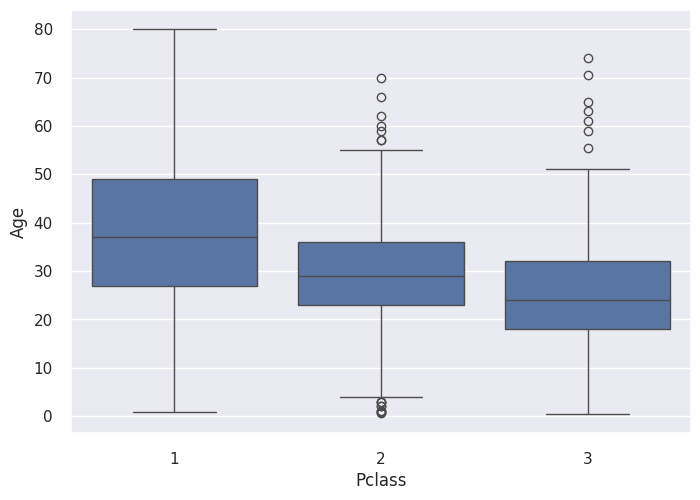

In [8]:
# 5. Xử lý dữ liệu thiếu trên biến Age bằng cách thay thế bằng giá trị trung bình tuổi:
# Hãy đưa ra quyết định dùng giá trị trung bình tuổi toàn bộ hành khách hay theo từng nhóm hạng vé (hạng hành khách: Pclass).
# Ta tiến hành làm các bước sau
# a. Sử dụng Seaborn để vẽ biểu đồ (Box plot) trực quan dữ liệu để xác định phân phối tuổi trên từng hạng hành khách.
# Nhận xét về tuổi trung bình giữa các nhóm hành khách. Từ đó đưa ra quyết định cách thay thế giá trị tuổi bị thiếu.
sns.boxplot(x='Pclass', y='Age', data=df)

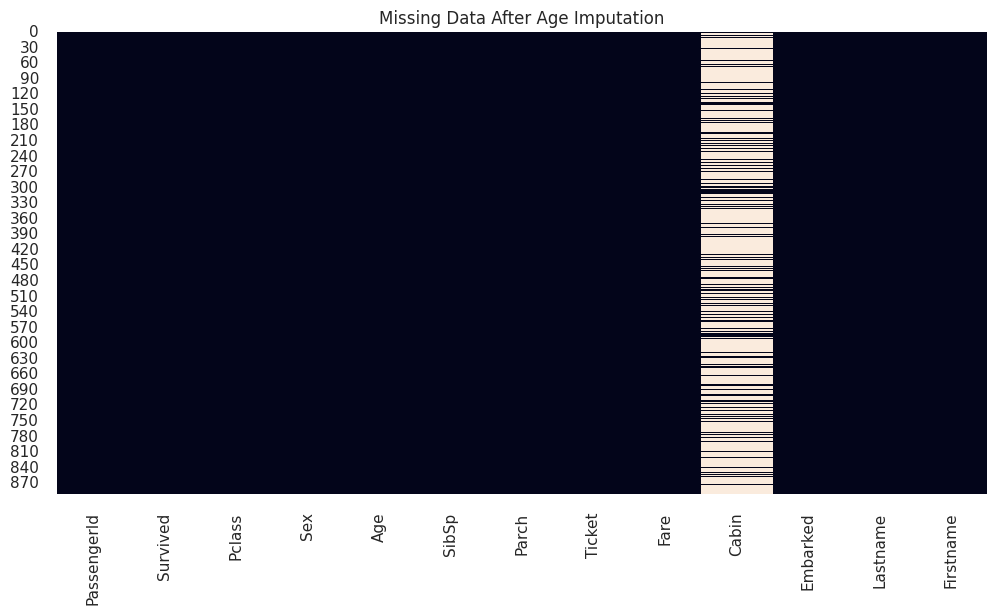

In [11]:
# b. Tiến hành thay thế giá trị Age bị thiếu. Sau đó, hiển thị kết quả dạng bảng và trực
# quan dữ liệu đã xử lý thiếu cho cột’Age’ bằng biểu đồ Heat map.
df["Age"] = df.groupby("Pclass")["Age"].transform(
    lambda x: x.fillna(x.mean())
)
df.isnull().sum()
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data After Age Imputation")
plt.show()

In [12]:
# 6. Xây dựng biến số Agegroup có thang đo thứ tự được ánh xạ theo thang đo khoảng dựa trên độ tuổi của hành khách như sau:
# (age =< 12] → Kid; (12, 18]: Teen, (18, 60]: Adult và ( age > 60): Older
bins = [0, 12, 18, 60, df['Age'].max()]
labels = ['Kid', 'Teen', 'Adult', 'Older']
df['Agegroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Lastname,Firstname,Agegroup
0,1,0,3,M,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris,Adult
1,2,1,1,F,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer),Adult
2,3,1,3,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina,Adult
3,4,1,1,F,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel),Adult
4,5,0,3,M,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry,Adult


In [13]:
# 7. Tiến hành thêm đặc trưng về danh xưng (namePrefix) trong xã hội bằng cách tách Mr, Mrs, Miss, Master ra khỏi cột 'secondName'
title_pattern = r'^\s*((?:Mr|Mrs|Miss|Master|Dr|Rev|Col|Mlle|Mme|Countess|Don|Lady|Capt|Sir|Jonkheer|Major|Ms|Dona)\.?)\s*'
df['namePrefix'] = df['Firstname'].str.extract(title_pattern, expand=False)
df['namePrefix'] = df['namePrefix'].fillna('Unknown')
df['Firstname'] = df['Firstname'].str.replace(title_pattern, '', regex=True).str.strip()

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Lastname,Firstname,Agegroup,namePrefix
0,1,0,3,M,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Owen Harris,Adult,Mr.
1,2,1,1,F,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,s. John Bradley (Florence Briggs Thayer),Adult,Mr
2,3,1,3,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Laina,Adult,Miss.
3,4,1,1,F,35.0,1,0,113803,53.1000,C123,S,Futrelle,s. Jacques Heath (Lily May Peel),Adult,Mr
4,5,0,3,M,35.0,0,0,373450,8.0500,NaN,S,Allen,William Henry,Adult,Mr.


In [15]:
# 8. Khai thác thêm thông tin số lượng thành viên đi theo nhóm thân quen (familySize) đối với mỗi hành khách trên chuyến hải trình; family size = 1+ SibSp + Parch
df['familySize'] = 1 + df['SibSp'] + df['Parch']

# Hiển thị 5 dòng đầu tiên để kiểm tra kết quả
display(df[['SibSp', 'Parch', 'familySize']].head())
display(df.head())

,SibSp,Parch,familySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Lastname,Firstname,Agegroup,namePrefix,familySize
0,1,0,3,M,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Owen Harris,Adult,Mr.,2
1,2,1,1,F,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,s. John Bradley (Florence Briggs Thayer),Adult,Mr,2
2,3,1,3,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Laina,Adult,Miss.,1
3,4,1,1,F,35.0,1,0,113803,53.1000,C123,S,Futrelle,s. Jacques Heath (Lily May Peel),Adult,Mr,2
4,5,0,3,M,35.0,0,0,373450,8.0500,NaN,S,Allen,William Henry,Adult,Mr.,1


In [16]:
# 9. Tạo thêm đặc trưng ‘Alone’ để xác định hành khách đi theo nhóm hay cá nhân bằng cách dựa trên familySize như sau: Nếu familySize = 1 thì giá trị Alone = 1 và ngược lại là 0.
df['Alone'] = 0
df.loc[df['familySize'] == 1, 'Alone'] = 1

# Hiển thị kết quả
display(df[['familySize', 'Alone']].head())
display(df.head())

,familySize,Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Lastname,Firstname,Agegroup,namePrefix,familySize,Alone
0,1,0,3,M,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Owen Harris,Adult,Mr.,2,0
1,2,1,1,F,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,s. John Bradley (Florence Briggs Thayer),Adult,Mr,2,0
2,3,1,3,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Laina,Adult,Miss.,1,1
3,4,1,1,F,35.0,1,0,113803,53.1000,C123,S,Futrelle,s. Jacques Heath (Lily May Peel),Adult,Mr,2,0
4,5,0,3,M,35.0,0,0,373450,8.0500,NaN,S,Allen,William Henry,Adult,Mr.,1,1


In [17]:
# 10. Tiến hành tách loại cabin (typeCabin) mà hành khách ở để lọc và phân tích đặc tính cabin.
# Loại cabin được kí hiệu bởi chữ cái đầu tiên. Lưu ý: Đối với dữ liệu cabin bị thiếu thì thay thế bằng “Unknown”
df['typeCabin'] = df['Cabin'].str[0]
df['typeCabin'] = df['typeCabin'].fillna('Unknown')

# Hiển thị kết quả kiểm tra
display(df[['Cabin', 'typeCabin']].head(10))

,Cabin,typeCabin
0,NaN,Unknown
1,C85,C
2,NaN,Unknown
3,C123,C
4,NaN,Unknown
5,NaN,Unknown
6,E46,E
7,NaN,Unknown
8,NaN,Unknown
9,NaN,Unknown


# PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH - EDA

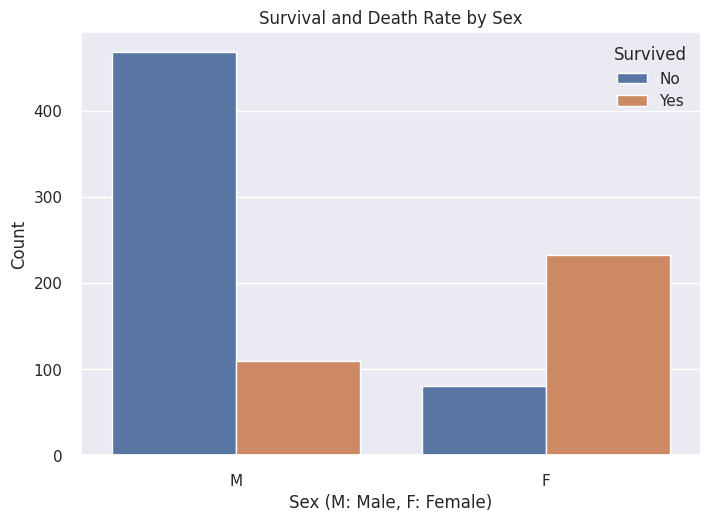

In [18]:
# 12. Trực quan thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival and Death Rate by Sex')
plt.xlabel('Sex (M: Male, F: Female)')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

Nhận xét:
- Tỉ lệ sống sót của nữ giới (F) cao hơn rất nhiều so với nam giới (M).
- Ngược lại, số lượng nam giới thiệt mạng chiếm tỉ trọng rất lớn trong tổng số hành khách.
- Giới tính là một đặc trưng quan trọng ảnh hưởng đến khả năng sống sót.

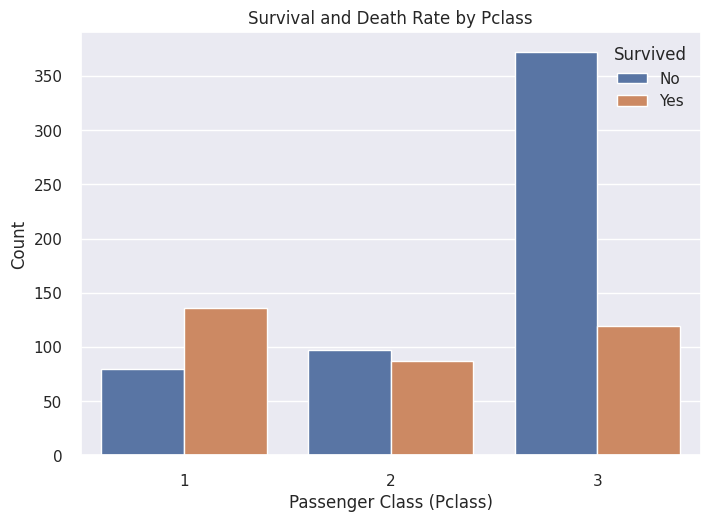

In [19]:
# 13. Trực quan thông tin hành khách sống sót trên từng nhóm phân loại hành khách (Pclass).
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival and Death Rate by Pclass')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

Nhận xét:
- Hành khách ở Hạng 1 (Pclass 1) có tỉ lệ sống sót cao nhất.
- Hành khách ở Hạng 3 (Pclass 3) có số lượng người thiệt mạng cao nhất, cho thấy điều kiện kinh tế/vị trí khoang tàu ảnh hưởng rõ rệt đến cơ hội cứu hộ.

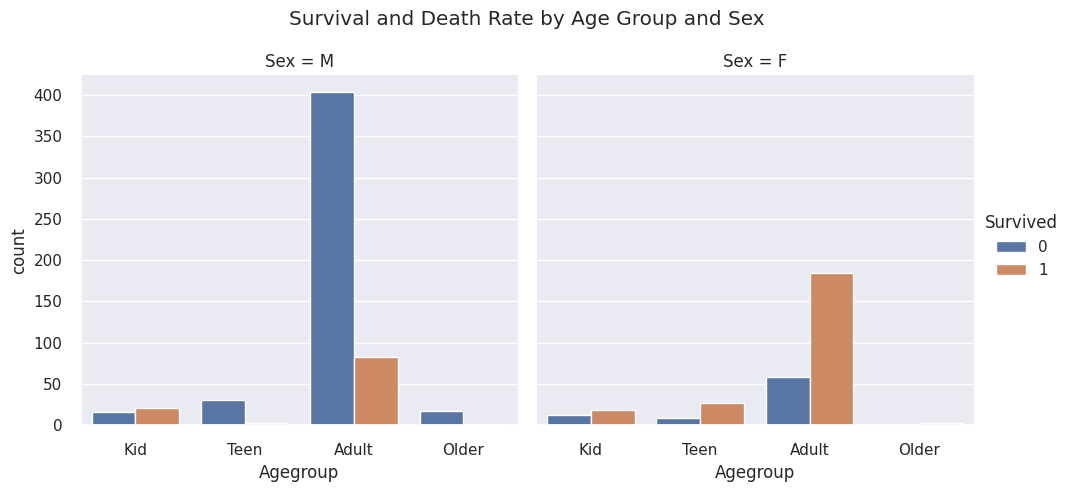

In [20]:
# 14. Trực quan thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác
sns.catplot(x='Agegroup', hue='Survived', col='Sex', data=df, kind='count')
plt.subplots_adjust(top=0.85)
plt.suptitle('Survival and Death Rate by Age Group and Sex')
plt.show()

Nhận xét:
- Ở cả hai giới tính, nhóm trẻ em (Kid) có tỉ lệ sống sót khá tốt so với các nhóm tuổi khác.
- Nhóm người lớn (Adult) nam giới có số lượng thiệt mạng cao nhất.
- Phụ nữ trong mọi nhóm tuổi đều có xác suất sống sót cao hơn nam giới cùng độ tuổi.

<function matplotlib.pyplot.show(close=None, block=None)>

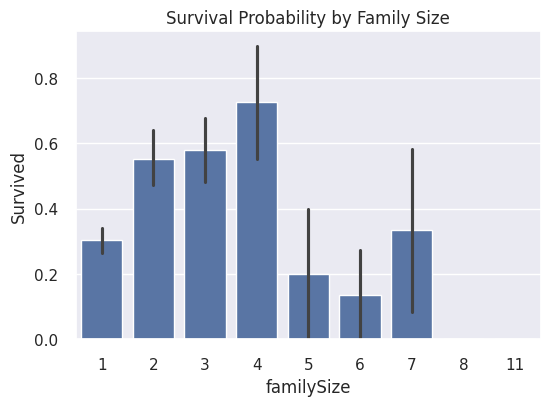

In [21]:
# 15. Trực quan xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng
plt.figure(figsize=(6, 4))
sns.barplot(x='familySize', y='Survived', data=df)
plt.title('Survival Probability by Family Size')
plt.show

Nhận xét:
- Những người đi một mình (familySize = 1) hoặc đi với gia đình quá đông (familySize > 4) có tỉ lệ sống sót thấp hơn.
- Nhóm có gia đình từ 2-4 người có xác suất sống sót tốt nhất, có thể do họ dễ dàng hỗ trợ nhau nhưng không quá cồng kềnh khi di chuyển.

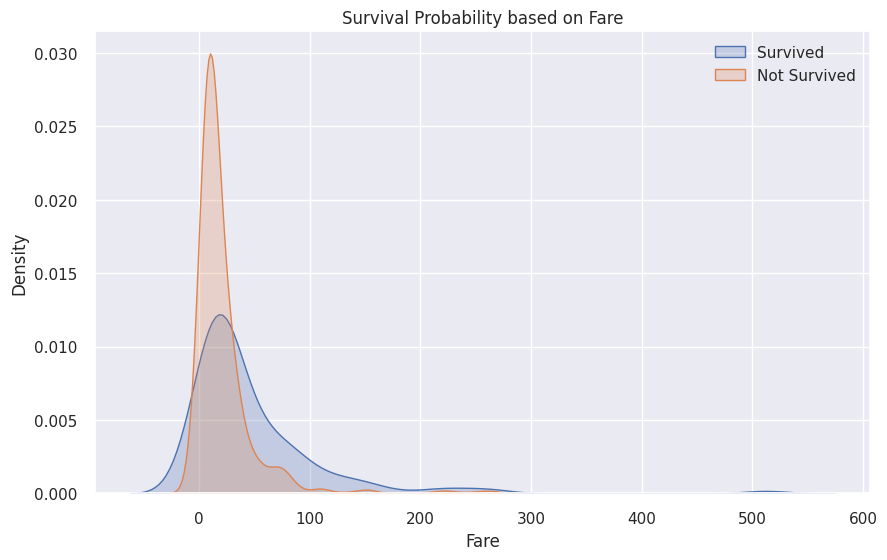

In [22]:
# 16. Trực quan xác suất hành khách sống sót dựa trên thông tin giá vé
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Survived'] == 1]['Fare'], label='Survived', fill=True)
sns.kdeplot(df[df['Survived'] == 0]['Fare'], label='Not Survived', fill=True)
plt.title('Survival Probability based on Fare')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.legend()
plt.show()

Nhận xét:
- Những hành khách trả mức giá vé (Fare) thấp có mật độ thiệt mạng rất cao.
- Biểu đồ cho thấy sự phân hóa: giá vé càng cao thì mật độ sống sót càng tăng, tương ứng với nhóm khách hàng thuộc tầng lớp thượng lưu.

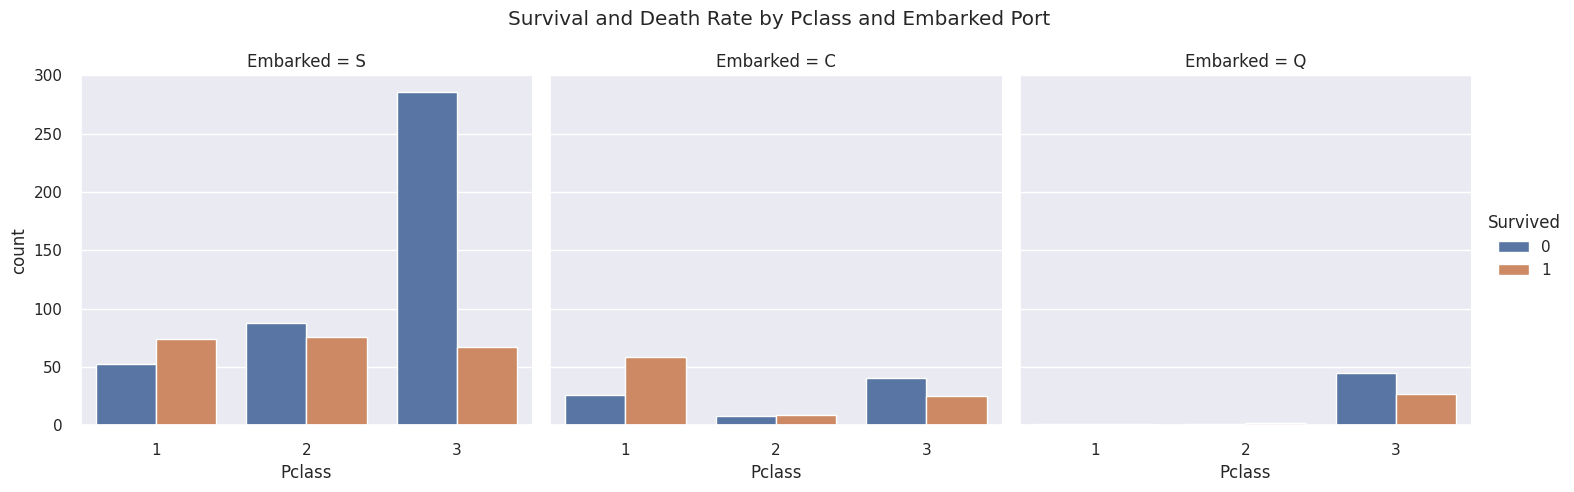

In [23]:
# 17. Trực quan số lượng người thiệt mạng và sống sót theo phân lớp (Pclass) hành khách và cảng sẽ cập bến
sns.catplot(x='Pclass', hue='Survived', col='Embarked', data=df, kind='count')
plt.subplots_adjust(top=0.85)
plt.suptitle('Survival and Death Rate by Pclass and Embarked Port')
plt.show()

Nhận xét:
- Cảng Cherbourg (C) có tỉ lệ sống sót cao hơn so với các cảng khác, đặc biệt là ở Hạng 1.
- Cảng Southampton (S) là nơi có lượng hành khách lên tàu đông nhất và cũng ghi nhận số lượng thiệt mạng lớn nhất, chủ yếu ở Hạng 3.